# ALPOD Lake Preprocessing for Ice Phenology Analysis
## Part 1: Load, Filter, and Calculate Metrics

**Goal:** Prep ALPOD lakes for multi-year ice detection

**Steps:**
1. Load ALPOD shapefile from GCS bucket
2. Filter to North Slope thermokarst region (lat >= 69°N)
3. Reproject to Alaska Albers Equal Area (EPSG:3338)
4. Recalculate lake morphometry metrics in this projection
5. Filter to lakes > 0.02 km² (reliable for S1/S2 detection)
6. Create spatial chunks (~1,500 lakes each)
7. Save processed chunks to bucket for GEE processing

**Output:** Spatially chunked lake datasets ready for 2019-2023 ice phenology analysis

---
## Setup

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import box
from sklearn.cluster import KMeans
import warnings
import os
import tempfile
import ee
from google.cloud import storage

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*Shapely GEOS.*')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Imports loaded")

Imports loaded


/opt/conda/envs/gee/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# Configuration
BUCKET = 'wustl-eeps-geospatial'
BASE_PATH = 'thermokarst_lakes'
ALPOD_PATH = f'gs://{BUCKET}/{BASE_PATH}/ALPODlakes/ALPODlakes.shp'
OUTPUT_PATH = f'gs://{BUCKET}/{BASE_PATH}/processed'
CHUNKS_PATH = f'gs://{BUCKET}/{BASE_PATH}/processed/chunks' 

# Initialize GEE (try without auth first)
try:
    ee.Initialize(project='eeps-geospatial')
    print("Earth Engine initialized successfully")
except ee.EEException:
    ee.Authenticate()
    ee.Initialize(project='eeps-geospatial')
    print("Earth Engine authenticated and initialized")

# Filtering parameters
MIN_LAT = 69.0  # North Slope thermokarst region
MIN_AREA_KM2 = 0.02  # Minimum area for reliable S1/S2 detection
TARGET_LAKES_PER_CHUNK = 1500  # Target chunk size

# Buffer distances (meters) for interior/landscape geometry computation
# -10m interior: Ensures S1/S2 pixels are fully within lake boundary
# 100m landscape: Captures immediate shoreline environment
INTERIOR_BUFFER_M = -10
LANDSCAPE_BUFFER_M = 100

# Projections
WGS84 = 'EPSG:4326'
ALASKA_ALBERS = 'EPSG:3338'  # Alaska Albers Equal Area

# Global variable for number of chunks (set after chunking)
n_chunks = None

print(f"\nConfiguration:")
print(f"  Input: {ALPOD_PATH}")
print(f"  Output: {OUTPUT_PATH}")
print(f"  Filter: lat >= {MIN_LAT}°N, area >= {MIN_AREA_KM2} km²")
print(f"  Target chunk size: {TARGET_LAKES_PER_CHUNK} lakes")

httplib2 transport does not support per-request timeout. Set the timeout when constructing the httplib2.Http instance.


httplib2 transport does not support per-request timeout. Set the timeout when constructing the httplib2.Http instance.


httplib2 transport does not support per-request timeout. Set the timeout when constructing the httplib2.Http instance.


httplib2 transport does not support per-request timeout. Set the timeout when constructing the httplib2.Http instance.


Earth Engine initialized successfully

Configuration:
  Input: gs://wustl-eeps-geospatial/thermokarst_lakes/ALPODlakes/ALPODlakes.shp
  Output: gs://wustl-eeps-geospatial/thermokarst_lakes/processed
  Filter: lat >= 69.0°N, area >= 0.02 km²
  Target chunk size: 1500 lakes


---
## Step 1: Load ALPOD Shapefile

In [3]:
# Fix PROJ database path if needed
import os
# Try to locate the correct PROJ data directory
try:
    import pyproj
    proj_data_dir = pyproj.datadir.get_data_dir()
    os.environ['PROJ_LIB'] = proj_data_dir
    print(f"Set PROJ_LIB to: {proj_data_dir}")
except Exception as e:
    print(f"Could not auto-detect PROJ data dir: {e}")
    print("Attempting to load shapefile anyway...")

# Load ALPOD shapefile from bucket
print("\nLoading ALPOD shapefile from bucket...")
lakes = gpd.read_file(ALPOD_PATH)

print(f"\nLoaded {len(lakes):,} lakes from ALPOD")
print(f"CRS: {lakes.crs}")

# Geometry validation
null_geom_count = lakes.geometry.isna().sum()
if null_geom_count > 0:
    print(f"WARNING: {null_geom_count} null geometries - removing")
    lakes = lakes[lakes.geometry.notna()].copy()

invalid_geom_count = (~lakes.geometry.is_valid).sum()
if invalid_geom_count > 0:
    print(f"WARNING: {invalid_geom_count} invalid geometries - repairing with buffer(0)")
    lakes.loc[~lakes.geometry.is_valid, 'geometry'] = lakes.loc[~lakes.geometry.is_valid, 'geometry'].buffer(0)
    
# Report final counts
print(f"After validation: {len(lakes):,} lakes with valid geometries")

print(f"\nColumns: {lakes.columns.tolist()}")
print(f"\nFirst few rows:")
print(lakes.head())

Set PROJ_LIB to: /opt/conda/envs/gee/share/proj

Loading ALPOD shapefile from bucket...



Loaded 801,895 lakes from ALPOD
CRS: EPSG:3338


After validation: 801,894 lakes with valid geometries

Columns: ['area', 'perimeter', 'id', 'geometry']

First few rows:
            area    perimeter  id  \
0  162419.231964  2437.168920   1   
1   27319.239899  1081.763907   2   
2   69230.709167  1664.266024   3   
3    5670.033508   384.649795   4   
4    4314.689270   321.756222   5   

                                            geometry  
0  POLYGON ((180860.756 2064396.126, 180861.41 20...  
1  POLYGON ((178711.35 2085654.803, 178712.001 20...  
2  POLYGON ((178664.804 2086307.966, 178665.455 2...  
3  POLYGON ((178583.858 2086977.788, 178583.828 2...  
4  POLYGON ((178550.017 2087492.664, 178550.667 2...  


In [4]:
# Check data types and basic stats
print("ALPOD attributes:")
print(lakes.dtypes)
print(f"\nGeometry type: {lakes.geometry.type.unique()}")
print(f"Bounds: {lakes.total_bounds}")

ALPOD attributes:
area          float64
perimeter     float64
id              int64
geometry     geometry
dtype: object

Geometry type: ['Polygon' 'MultiPolygon']


Bounds: [-1674816.70993491   417614.7985957   1491950.71746127  2375493.39808125]


---
## Step 2: Initial Filtering - Geographic Region

In [5]:
# Calculate centroids to filter by latitude
# Do this in WGS84 before reprojection
if lakes.crs != WGS84:
    lakes_wgs84 = lakes.to_crs(WGS84)
else:
    lakes_wgs84 = lakes.copy()

# Get centroid latitude
lakes_wgs84['centroid_lat'] = lakes_wgs84.geometry.centroid.y
lakes_wgs84['centroid_lon'] = lakes_wgs84.geometry.centroid.x

# Filter to North Slope (thermokarst region)
lakes_northslope = lakes_wgs84[lakes_wgs84['centroid_lat'] >= MIN_LAT].copy()

print(f"Filtering to North Slope (lat >= {MIN_LAT}°N):")
print(f"  Original: {len(lakes):,} lakes")
print(f"  Filtered: {len(lakes_northslope):,} lakes")
print(f"  Removed: {len(lakes) - len(lakes_northslope):,} lakes")

print(f"\nLatitude range: {lakes_northslope['centroid_lat'].min():.2f}°N to {lakes_northslope['centroid_lat'].max():.2f}°N")
print(f"Longitude range: {lakes_northslope['centroid_lon'].min():.2f}° to {lakes_northslope['centroid_lon'].max():.2f}°")

/tmp/ipykernel_24015/3808444040.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lakes_wgs84['centroid_lat'] = lakes_wgs84.geometry.centroid.y


/tmp/ipykernel_24015/3808444040.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lakes_wgs84['centroid_lon'] = lakes_wgs84.geometry.centroid.x


Filtering to North Slope (lat >= 69.0°N):
  Original: 801,894 lakes
  Filtered: 128,197 lakes
  Removed: 673,697 lakes

Latitude range: 69.00°N to 71.36°N
Longitude range: -163.85° to -141.02°


Loading Natural Earth data for basemap...


Loaded 10m resolution Natural Earth data

Checking for phenology data...


  Loaded phenology for 31,108 area-filtered lakes
  30,862 lakes with complete phenology detection
  246 area-filtered lakes without complete phenology



Two-color categories (area >= 0.02 km²):
  Blue: 30,862 lakes with complete phenology
  Dark pink: 246 lakes above cutoff, no complete phenology


/tmp/ipykernel_24015/3173258251.py:247: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


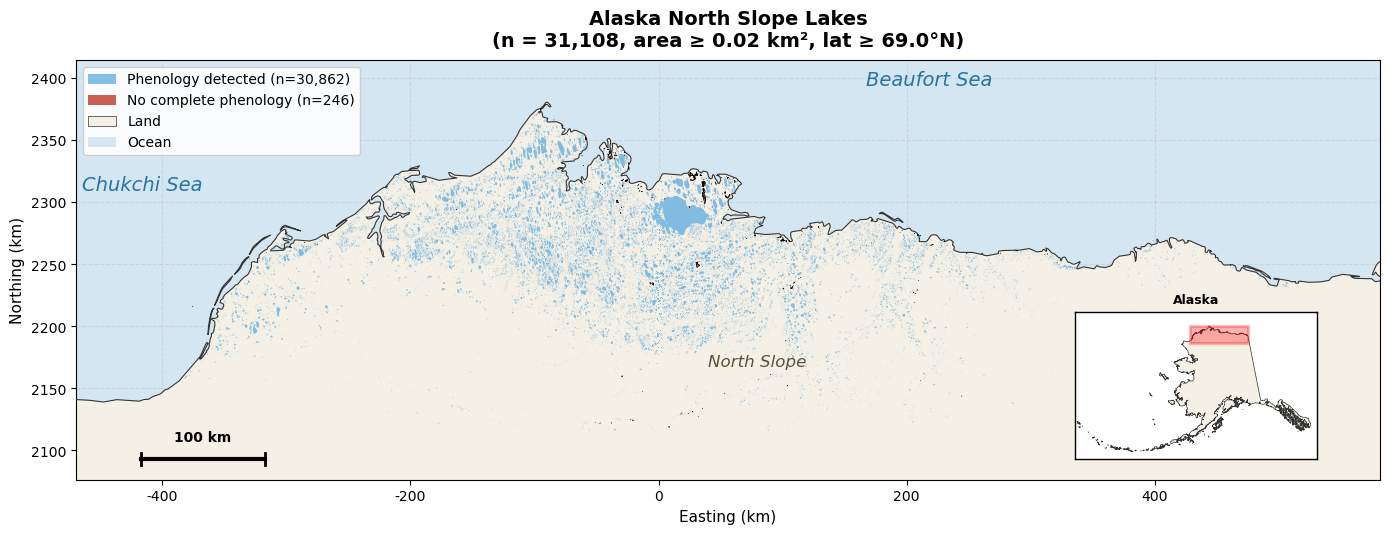


Saved: figures/working/north_slope_lakes_distribution.png
Saved: figures/manuscript/fig01_study_area.png (300 dpi)
Saved: figure_data/fig01_study_area.csv

Figure 1: 30,862 detected + 246 undetected = 31,108 lakes


In [6]:
# =============================================================================
# Study Area Map (Figure 1) - THREE-COLOR CATEGORIES
# =============================================================================
# Blue = phenology detected, Dark pink = above size cutoff but no phenology,
# Light gray = below size cutoff

import geopandas as gpd
from shapely.geometry import box
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
import os

# Set publication-quality styling (The Cryosphere: 300 dpi, 8-10pt fonts)
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'figure.dpi': 100,  # Display dpi
    'savefig.dpi': 300  # Output dpi
})

print("Loading Natural Earth data for basemap...")

# Load Natural Earth data (10m resolution for detail)
try:
    coastline = gpd.read_file('https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip')
    land = gpd.read_file('https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip')
    ocean = gpd.read_file('https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip')
    print("Loaded 10m resolution Natural Earth data")
except Exception as e:
    print(f"Error loading 10m data: {e}")
    coastline = gpd.read_file('https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip')
    land = gpd.read_file('https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip')
    ocean = gpd.read_file('https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip')
    print("Loaded 50m resolution Natural Earth data (fallback)")

# Try to load phenology results to determine detection success
PHENOLOGY_FILE = 'alaska_lakes_ice_phenology_2019-2023.csv'
detected_lakes = set()
all_phenology_lakes = set()
phenology_available = False

print("\nChecking for phenology data...")
if os.path.exists(PHENOLOGY_FILE):
    try:
        phenology = pd.read_csv(PHENOLOGY_FILE)
        # All lakes in the CSV are above the size cutoff (31,108)
        all_phenology_lakes = set(phenology['lake_id'].unique())
        # A lake has successful detection if BOTH ice-off and ice-on were detected in ANY year
        complete_records = phenology[
            phenology['ice_off_doy'].notna() &
            phenology['ice_on_doy'].notna()
        ]
        detected_lakes = set(complete_records['lake_id'].unique())
        phenology_available = True
        print(f"  Loaded phenology for {len(all_phenology_lakes):,} area-filtered lakes")
        print(f"  {len(detected_lakes):,} lakes with complete phenology detection")
        print(f"  {len(all_phenology_lakes) - len(detected_lakes):,} area-filtered lakes without complete phenology")
    except Exception as e:
        print(f"  Warning: Could not load phenology data: {e}")
        print("  Using uniform coloring (all lakes blue)")
else:
    print(f"  Phenology file not found: {PHENOLOGY_FILE}")
    print("  Run notebook 03 first to generate phenology data, then re-run this cell")
    print("  For now, using uniform coloring (all lakes blue)")

# Reproject to Alaska Albers (EPSG:3338)
coastline_albers = coastline.to_crs(ALASKA_ALBERS)
land_albers = land.to_crs(ALASKA_ALBERS)
ocean_albers = ocean.to_crs(ALASKA_ALBERS)
lakes_albers_plot = lakes_northslope.to_crs(ALASKA_ALBERS)

# Only plot area-filtered lakes (>= 0.02 km²); below-cutoff lakes are
# sub-pixel at the map's rendered resolution and invisible.
lakes_above_cutoff = lakes_albers_plot[lakes_albers_plot['id'].isin(all_phenology_lakes)]

if phenology_available:
    mask_detected = lakes_above_cutoff['id'].isin(detected_lakes)
    lakes_cat1_detected = lakes_above_cutoff[mask_detected]
    lakes_cat2_no_phenology = lakes_above_cutoff[~mask_detected]

    n_detected = len(lakes_cat1_detected)
    n_no_phenology = len(lakes_cat2_no_phenology)

    print(f"\nTwo-color categories (area >= {MIN_AREA_KM2} km\u00b2):")
    print(f"  Blue: {n_detected:,} lakes with complete phenology")
    print(f"  Dark pink: {n_no_phenology:,} lakes above cutoff, no complete phenology")
else:
    lakes_cat1_detected = lakes_above_cutoff
    lakes_cat2_no_phenology = lakes_above_cutoff.iloc[0:0]
    n_detected = len(lakes_above_cutoff)
    n_no_phenology = 0

# Define study area bounds (tighter around lakes)
lake_bounds = lakes_albers_plot.total_bounds  # [minx, miny, maxx, maxy]
buffer_x = (lake_bounds[2] - lake_bounds[0]) * 0.08
buffer_y = (lake_bounds[3] - lake_bounds[1]) * 0.15

xlim = (lake_bounds[0] - buffer_x, lake_bounds[2] + buffer_x)
ylim = (lake_bounds[1] - buffer_y, lake_bounds[3] + buffer_y)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Clip data to study area for faster rendering
clip_box = box(xlim[0] - 100000, ylim[0] - 100000, xlim[1] + 100000, ylim[1] + 200000)
clip_gdf = gpd.GeoDataFrame(geometry=[clip_box], crs=ALASKA_ALBERS)

# Plot ocean background
ocean_clipped = gpd.clip(ocean_albers, clip_gdf)
if len(ocean_clipped) > 0:
    ocean_clipped.plot(ax=ax, color='#d4e6f1', edgecolor='none', zorder=1)

# Plot land
land_clipped = gpd.clip(land_albers, clip_gdf)
if len(land_clipped) > 0:
    land_clipped.plot(ax=ax, color='#f5f0e6', edgecolor='none', zorder=2)

# Plot coastline
coast_clipped = gpd.clip(coastline_albers, clip_gdf)
if len(coast_clipped) > 0:
    coast_clipped.plot(ax=ax, color='#333333', linewidth=0.8, zorder=3)

# Plot lakes -- two categories
if len(lakes_cat2_no_phenology) > 0:
    lakes_cat2_no_phenology.plot(ax=ax, markersize=12, alpha=0.9, color='#c0392b',
                                 edgecolor='black', linewidth=0.3, zorder=5)
if len(lakes_cat1_detected) > 0:
    lakes_cat1_detected.plot(ax=ax, markersize=1.5, alpha=0.6, color='#3498db', zorder=6)

# Set limits
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Add scale bar (manual - 100 km)
scale_length_m = 100000  # 100 km
scale_x = xlim[0] + (xlim[1] - xlim[0]) * 0.05
scale_y = ylim[0] + (ylim[1] - ylim[0]) * 0.05
ax.plot([scale_x, scale_x + scale_length_m], [scale_y, scale_y],
        color='black', linewidth=3, zorder=10)
ax.plot([scale_x, scale_x], [scale_y - 5000, scale_y + 5000],
        color='black', linewidth=2, zorder=10)
ax.plot([scale_x + scale_length_m, scale_x + scale_length_m], [scale_y - 5000, scale_y + 5000],
        color='black', linewidth=2, zorder=10)
ax.text(scale_x + scale_length_m/2, scale_y + 12000, '100 km',
        ha='center', va='bottom', fontsize=10, fontweight='bold', zorder=10)

# Add sea labels (approximate positions in EPSG:3338)
from pyproj import Transformer
transformer = Transformer.from_crs('EPSG:4326', ALASKA_ALBERS, always_xy=True)

# Beaufort Sea label (approx -148, 71.5)
beau_x, beau_y = transformer.transform(-148, 71.5)
ax.text(beau_x, beau_y, 'Beaufort Sea', fontsize=14, fontstyle='italic',
        color='#2874a6', ha='center', va='center', zorder=5)

# Chukchi Sea label (approx -165, 70.5)
chuk_x, chuk_y = transformer.transform(-165, 70.5)
if xlim[0] < chuk_x < xlim[1] and ylim[0] < chuk_y < ylim[1]:
    ax.text(chuk_x, chuk_y, 'Chukchi Sea', fontsize=14, fontstyle='italic',
            color='#2874a6', ha='center', va='center', zorder=5)

# Arctic Ocean label (top center)
arctic_x, arctic_y = transformer.transform(-153, 72.5)
if ylim[0] < arctic_y < ylim[1]:
    ax.text(arctic_x, arctic_y, 'Arctic Ocean', fontsize=16, fontstyle='italic',
            color='#2874a6', ha='center', va='center', fontweight='bold', zorder=5)

# Add North Slope label on land
ns_x, ns_y = transformer.transform(-152, 69.5)
ax.text(ns_x, ns_y, 'North Slope', fontsize=12, fontstyle='italic',
        color='#5d4e37', ha='center', va='center', zorder=5)

# Title and labels
n_total = len(lakes_above_cutoff)
ax.set_title(f'Alaska North Slope Lakes\n(n = {n_total:,}, area \u2265 {MIN_AREA_KM2} km\u00b2, lat \u2265 {MIN_LAT}\u00b0N)',
             fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Easting (km)', fontsize=11)
ax.set_ylabel('Northing (km)', fontsize=11)

# Format axis labels in km
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}'))

# Grid
ax.grid(True, alpha=0.3, linestyle='--', zorder=0)

# -------------------------------------------------------------------------
# Inset map showing Alaska with study area box
# -------------------------------------------------------------------------
ax_inset = inset_axes(ax, width="25%", height="35%", loc='lower right',
                       borderpad=1.5)

# Load Alaska boundary for inset (use admin boundaries)
try:
    admin = gpd.read_file('https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces.zip')
    alaska = admin[admin['name'] == 'Alaska']
    alaska_albers = alaska.to_crs(ALASKA_ALBERS)
except:
    alaska_box = box(-2500000, 300000, 1500000, 2600000)
    alaska_clip = gpd.GeoDataFrame(geometry=[alaska_box], crs=ALASKA_ALBERS)
    alaska_albers = gpd.clip(land_albers, alaska_clip)

# Plot Alaska in inset
alaska_albers.plot(ax=ax_inset, color='#f5f0e6', edgecolor='#333333', linewidth=0.5)

# Add study area box
study_box = mpatches.Rectangle(
    (lake_bounds[0], lake_bounds[1]),
    lake_bounds[2] - lake_bounds[0],
    lake_bounds[3] - lake_bounds[1],
    linewidth=2, edgecolor='red', facecolor='red', alpha=0.3
)
ax_inset.add_patch(study_box)

# Set inset limits to show all of Alaska
ax_inset.set_xlim(-2200000, 1600000)
ax_inset.set_ylim(300000, 2600000)
ax_inset.set_xticks([])
ax_inset.set_yticks([])
ax_inset.set_title('Alaska', fontsize=9, fontweight='bold')

# Add box outline around inset
for spine in ax_inset.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

# Legend -- two categories
if phenology_available:
    legend_elements = [
        mpatches.Patch(facecolor='#3498db', alpha=0.6,
                       label=f'Phenology detected (n={n_detected:,})'),
        mpatches.Patch(facecolor='#c0392b', alpha=0.8,
                       label=f'No complete phenology (n={n_no_phenology:,})'),
        mpatches.Patch(facecolor='#f5f0e6', edgecolor='#333333', linewidth=0.5, label='Land'),
        mpatches.Patch(facecolor='#d4e6f1', label='Ocean'),
    ]
else:
    legend_elements = [
        mpatches.Patch(facecolor='#3498db', alpha=0.6, label=f'Lakes (n={n_total:,})'),
        mpatches.Patch(facecolor='#f5f0e6', edgecolor='#333333', linewidth=0.5, label='Land'),
        mpatches.Patch(facecolor='#d4e6f1', label='Ocean'),
    ]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.9)

plt.tight_layout()

# Save figures
os.makedirs('figures/working', exist_ok=True)
os.makedirs('figures/manuscript', exist_ok=True)
os.makedirs('figure_data', exist_ok=True)

plt.savefig('figures/working/north_slope_lakes_distribution.png', dpi=150, bbox_inches='tight')
plt.savefig('figures/manuscript/fig01_study_area.png', dpi=300, bbox_inches='tight')
plt.show()

# Export figure data as CSV
fig1_data = pd.DataFrame({
    'lake_id': lakes_above_cutoff['id'],
    'centroid_lon': lakes_above_cutoff['centroid_lon'],
    'centroid_lat': lakes_above_cutoff['centroid_lat'],
    'area_km2': lakes_above_cutoff['area'] / 1e6,
    'phenology_detected': lakes_above_cutoff['id'].isin(detected_lakes).astype(int)
})
fig1_data.to_csv('figure_data/fig01_study_area.csv', index=False)

print("\nSaved: figures/working/north_slope_lakes_distribution.png")
print("Saved: figures/manuscript/fig01_study_area.png (300 dpi)")
print("Saved: figure_data/fig01_study_area.csv")
if phenology_available:
    print(f"\nFigure 1: {n_detected:,} detected + {n_no_phenology:,} undetected = {n_total:,} lakes")
else:
    print(f"\nFigure 1: {n_total:,} lakes (phenology data not yet available)")
    print("Re-run this cell after running notebook 03 to show detection status")


---
## Step 3: Reproject to Alaska Albers Equal Area (EPSG:3338)

In [7]:
# Reproject to Alaska Albers for accurate area/perimeter calculations
print(f"Reprojecting from {WGS84} to {ALASKA_ALBERS}...")
lakes_albers = lakes_northslope.to_crs(ALASKA_ALBERS)

print(f"Reprojection complete!")
print(f"New CRS: {lakes_albers.crs}")
print(f"Units: meters")

Reprojecting from EPSG:4326 to EPSG:3338...


Reprojection complete!
New CRS: EPSG:3338
Units: meters


---
## Step 4: Calculate Lake Morphometry Metrics

In [8]:
print("Calculating lake morphometry metrics in EPSG:3338...")

# Basic metrics
lakes_albers['lake_area_m2'] = lakes_albers.geometry.area
lakes_albers['lake_area_km2'] = lakes_albers['lake_area_m2'] / 1e6
lakes_albers['lake_perim_m'] = lakes_albers.geometry.length

# Circularity
lakes_albers['circularity'] = (
    4 * np.pi * lakes_albers['lake_area_m2'] / 
    (lakes_albers['lake_perim_m'] ** 2)
)

# Shoreline Development Index (Hutchinson 1957)
lakes_albers['shoreline_dev'] = (
    lakes_albers['lake_perim_m'] / 
    (2 * np.sqrt(np.pi * lakes_albers['lake_area_m2']))
)

# Convexity (solidity)
convex_hulls = lakes_albers.geometry.convex_hull
convex_areas = convex_hulls.area
lakes_albers['convexity'] = lakes_albers['lake_area_m2'] / convex_areas

# Centroid coordinates in Albers projection (for spatial analysis)
centroids_albers = lakes_albers.geometry.centroid
lakes_albers['centroid_x_albers'] = centroids_albers.x
lakes_albers['centroid_y_albers'] = centroids_albers.y

print("Metrics calculated!")
print(f"\nMetrics summary:")
print(lakes_albers[['lake_area_km2', 'lake_perim_m', 'circularity', 
                     'shoreline_dev', 'convexity']].describe())  # Changed fractal_dim → shoreline_dev

Calculating lake morphometry metrics in EPSG:3338...


Metrics calculated!

Metrics summary:
       lake_area_km2   lake_perim_m    circularity  shoreline_dev  \
count  128197.000000  128197.000000  128197.000000  128197.000000   
mean        0.077731     927.169579       0.405084       1.673953   
std         2.450187    2295.861868       0.137897       0.430775   
min         0.001000     133.240354       0.009952       1.110176   
25%         0.002037     241.650060       0.306000       1.402402   
50%         0.004906     401.856010       0.417145       1.548304   
75%         0.018948     855.578068       0.508458       1.807755   
max       858.993864  508919.141269       0.811365      10.024296   

           convexity  
count  128197.000000  
mean        0.801535  
std         0.105620  
min         0.111598  
25%         0.745098  
50%         0.822222  
75%         0.879656  
max         1.000000  


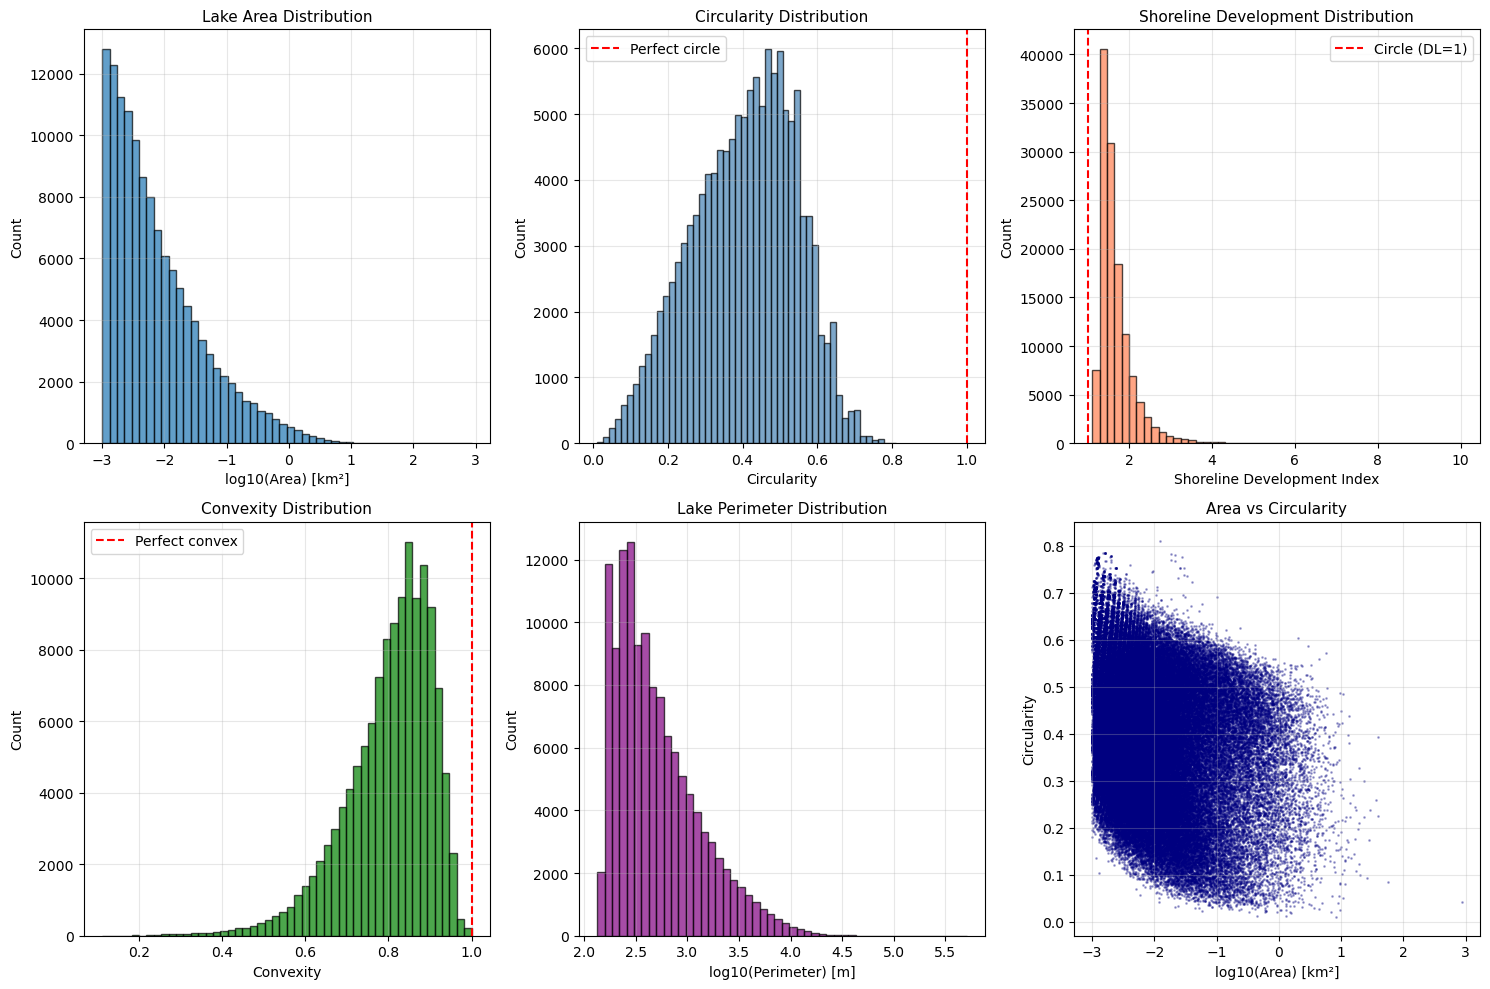

Saved: figures/working/lake_metrics_distributions.png


In [9]:
# Visualize metric distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Area (log scale)
axes[0, 0].hist(np.log10(lakes_albers['lake_area_km2']), bins=50, 
                edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('log10(Area) [km²]')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Lake Area Distribution')
axes[0, 0].grid(alpha=0.3)

# Circularity
axes[0, 1].hist(lakes_albers['circularity'], bins=50, 
                edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].set_xlabel('Circularity')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Circularity Distribution')
axes[0, 1].axvline(1.0, color='red', linestyle='--', label='Perfect circle')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Shoreline Development Index
axes[0, 2].hist(lakes_albers['shoreline_dev'], bins=50, 
                edgecolor='black', alpha=0.7, color='coral')
axes[0, 2].set_xlabel('Shoreline Development Index')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Shoreline Development Distribution')
axes[0, 2].axvline(1.0, color='red', linestyle='--', label='Circle (DL=1)')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Convexity
axes[1, 0].hist(lakes_albers['convexity'], bins=50, 
                edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Convexity')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Convexity Distribution')
axes[1, 0].axvline(1.0, color='red', linestyle='--', label='Perfect convex')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Perimeter
axes[1, 1].hist(np.log10(lakes_albers['lake_perim_m']), bins=50, 
                edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('log10(Perimeter) [m]')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Lake Perimeter Distribution')
axes[1, 1].grid(alpha=0.3)

# Area vs Circularity scatter
axes[1, 2].scatter(np.log10(lakes_albers['lake_area_km2']), 
                   lakes_albers['circularity'], 
                   s=1, alpha=0.3, color='navy')
axes[1, 2].set_xlabel('log10(Area) [km²]')
axes[1, 2].set_ylabel('Circularity')
axes[1, 2].set_title('Area vs Circularity')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/working/lake_metrics_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/working/lake_metrics_distributions.png")

---
## Step 5: Filter by Size (> 0.02 km²)

In [10]:
# Filter to lakes large enough for reliable S1/S2 detection
lakes_final = lakes_albers[lakes_albers['lake_area_km2'] > MIN_AREA_KM2].copy()

print(f"Filtering by size (area > {MIN_AREA_KM2} km²):")
print(f"  Before: {len(lakes_albers):,} lakes")
print(f"  After: {len(lakes_final):,} lakes")
print(f"  Removed: {len(lakes_albers) - len(lakes_final):,} lakes")

print(f"\nFinal dataset statistics:")
print(f"  Total lakes: {len(lakes_final):,}")
print(f"  Area range: {lakes_final['lake_area_km2'].min():.4f} - {lakes_final['lake_area_km2'].max():.2f} km²")
print(f"  Median area: {lakes_final['lake_area_km2'].median():.4f} km²")
print(f"  Latitude range: {lakes_final['centroid_lat'].min():.2f}°N - {lakes_final['centroid_lat'].max():.2f}°N")

Filtering by size (area > 0.02 km²):
  Before: 128,197 lakes
  After: 31,108 lakes
  Removed: 97,089 lakes

Final dataset statistics:
  Total lakes: 31,108
  Area range: 0.0200 - 858.99 km²
  Median area: 0.0648 km²
  Latitude range: 69.00°N - 71.36°N


---
## Step 6: Create Spatial Chunks

In [11]:
def create_spatial_chunks(gdf, target_size=1500):
    """
    Create spatial chunks using K-means clustering on centroids.
    Targets approximately target_size lakes per chunk.
    
    Returns:
        gdf: GeoDataFrame with 'chunk_id' column added
        chunk_stats_df: DataFrame with statistics for each chunk
        n_chunks: Number of chunks created
    """
    global n_chunks  # Update global variable
    
    # Calculate number of chunks needed
    n_chunks = int(np.ceil(len(gdf) / target_size))
    
    print(f"Creating {n_chunks} spatial chunks (target: {target_size} lakes/chunk)...")
    
    # Use centroids for clustering
    coords = np.column_stack([gdf['centroid_lon'].values, 
                               gdf['centroid_lat'].values])
    
    # K-means clustering
    kmeans = KMeans(n_clusters=n_chunks, random_state=RANDOM_SEED, n_init=10)
    gdf['chunk_id'] = kmeans.fit_predict(coords)
    
    # Report chunk sizes and bounds
    print(f"\nChunk summary:")
    chunk_stats = []
    
    for chunk_id in sorted(gdf['chunk_id'].unique()):
        chunk_data = gdf[gdf['chunk_id'] == chunk_id]
        
        stats = {
            'chunk_id': chunk_id,
            'n_lakes': len(chunk_data),
            'lon_min': chunk_data['centroid_lon'].min(),
            'lon_max': chunk_data['centroid_lon'].max(),
            'lat_min': chunk_data['centroid_lat'].min(),
            'lat_max': chunk_data['centroid_lat'].max(),
            'area_min_km2': chunk_data['lake_area_km2'].min(),
            'area_max_km2': chunk_data['lake_area_km2'].max(),
            'area_median_km2': chunk_data['lake_area_km2'].median()
        }
        chunk_stats.append(stats)
        
        print(f"  Chunk {chunk_id:2d}: {stats['n_lakes']:5d} lakes | "
              f"Lon: {stats['lon_min']:7.2f} to {stats['lon_max']:7.2f} | "
              f"Lat: {stats['lat_min']:6.2f} to {stats['lat_max']:6.2f}")
    
    chunk_stats_df = pd.DataFrame(chunk_stats)
    
    return gdf, chunk_stats_df, n_chunks

# Create chunks (n_chunks is set globally by the function)
lakes_chunked, chunk_stats, n_chunks = create_spatial_chunks(lakes_final, 
                                                               target_size=TARGET_LAKES_PER_CHUNK)
print(f"\nGlobal n_chunks set to: {n_chunks}")

Creating 21 spatial chunks (target: 1500 lakes/chunk)...



Chunk summary:
  Chunk  0:  1659 lakes | Lon: -157.46 to -156.32 | Lat:  69.00 to  70.81
  Chunk  1:  1402 lakes | Lon: -150.59 to -149.50 | Lat:  69.00 to  70.50
  Chunk  2:  2172 lakes | Lon: -149.58 to -148.46 | Lat:  69.00 to  70.51
  Chunk  3:  1002 lakes | Lon: -161.09 to -159.72 | Lat:  69.00 to  70.66
  Chunk  4:  2243 lakes | Lon: -155.63 to -154.36 | Lat:  70.14 to  71.16
  Chunk  5:   408 lakes | Lon: -144.86 to -141.02 | Lat:  69.06 to  70.12
  Chunk  6:  1726 lakes | Lon: -153.57 to -152.26 | Lat:  69.89 to  70.91
  Chunk  7:  1704 lakes | Lon: -158.91 to -157.86 | Lat:  69.00 to  70.81
  Chunk  8:   753 lakes | Lon: -147.16 to -144.89 | Lat:  69.02 to  70.19
  Chunk  9:   460 lakes | Lon: -163.58 to -162.00 | Lat:  69.03 to  70.08
  Chunk 10:  1440 lakes | Lon: -153.98 to -152.58 | Lat:  69.01 to  70.33
  Chunk 11:  1392 lakes | Lon: -155.66 to -154.10 | Lat:  69.00 to  70.22
  Chunk 12:  1834 lakes | Lon: -151.66 to -150.52 | Lat:  69.00 to  70.48
  Chunk 13:  2001 lake

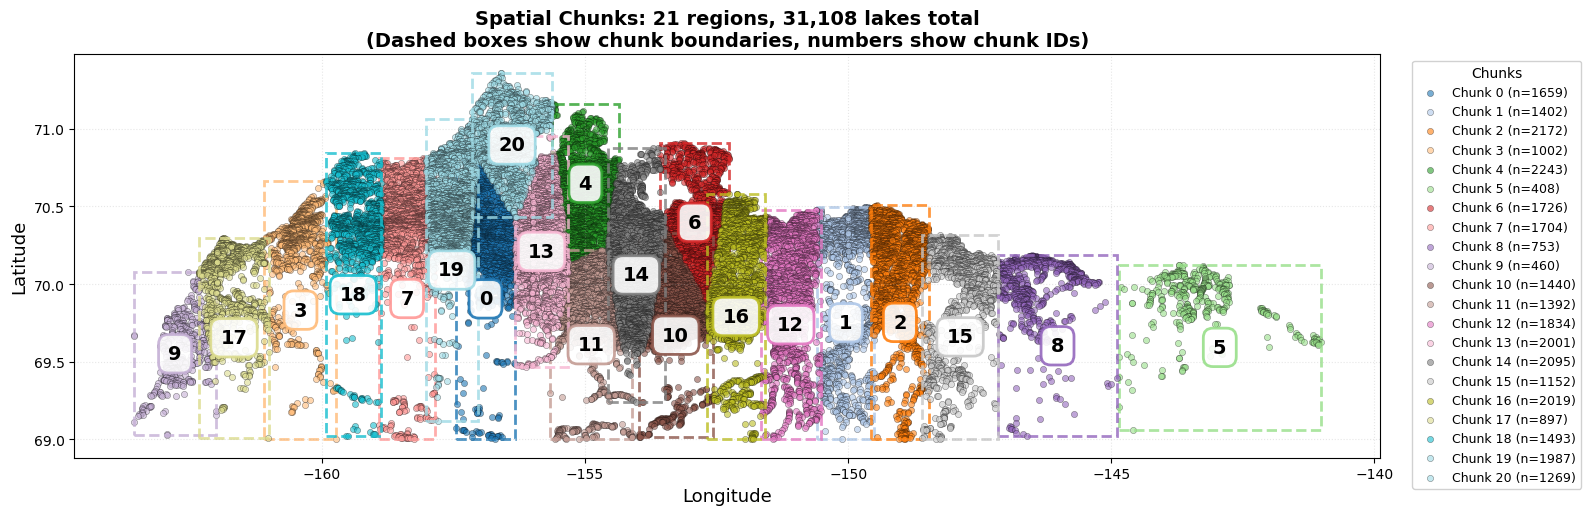

Saved: figures/working/spatial_chunks.png


In [12]:
# Visualize chunks with clear boundaries
from matplotlib.patches import Rectangle
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(16, 10))

# Get color map
n_chunks = len(lakes_chunked['chunk_id'].unique())
colors = cm.tab20(np.linspace(0, 1, n_chunks))

# Plot each chunk
for i, chunk_id in enumerate(sorted(lakes_chunked['chunk_id'].unique())):
    chunk_data = lakes_chunked[lakes_chunked['chunk_id'] == chunk_id]
    
    # Plot lakes as points (centroids)
    ax.scatter(chunk_data['centroid_lon'], chunk_data['centroid_lat'],
               s=20, alpha=0.6, color=colors[i],
               label=f'Chunk {chunk_id} (n={len(chunk_data)})',
               edgecolors='black', linewidths=0.3)
    
    # Draw bounding box for each chunk
    lon_min = chunk_data['centroid_lon'].min()
    lon_max = chunk_data['centroid_lon'].max()
    lat_min = chunk_data['centroid_lat'].min()
    lat_max = chunk_data['centroid_lat'].max()
    
    width = lon_max - lon_min
    height = lat_max - lat_min
    
    rect = Rectangle((lon_min, lat_min), width, height,
                     linewidth=2, edgecolor=colors[i],
                     facecolor='none', linestyle='--', alpha=0.8)
    ax.add_patch(rect)
    
    # Add chunk label at center
    center_lon = (lon_min + lon_max) / 2
    center_lat = (lat_min + lat_max) / 2
    ax.text(center_lon, center_lat, f'{chunk_id}',
            fontsize=14, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                     edgecolor=colors[i], linewidth=2, alpha=0.9))

ax.set_xlabel('Longitude', fontsize=13)
ax.set_ylabel('Latitude', fontsize=13)
ax.set_title(f'Spatial Chunks: {n_chunks} regions, {len(lakes_chunked):,} lakes total\n'
             f'(Dashed boxes show chunk boundaries, numbers show chunk IDs)',
             fontsize=14, fontweight='bold')

# Fix aspect ratio for high-latitude distortion
# At ~70°N, longitude degrees are ~1/3 the width of latitude degrees
mean_lat = lakes_chunked['centroid_lat'].mean()
aspect_ratio = 1.0 / np.cos(np.radians(mean_lat))
ax.set_aspect(aspect_ratio)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9,
         title='Chunks', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('figures/working/spatial_chunks.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/working/spatial_chunks.png")

---
## Step 7: Save Processed Data

In [13]:
# =============================================================================
# UPLOAD ALPOD TO GEE ASSET (ONE-TIME ONLY)
# =============================================================================
# Set to False after asset is uploaded
UPLOAD_ALPOD_ASSET = False

if UPLOAD_ALPOD_ASSET:
    print("Uploading ALPOD to GEE Asset...")
    print("(Direct from GCS )\n")
    
    !/opt/conda/bin/earthengine upload table \
        --asset_id=projects/eeps-geospatial/assets/ALPOD_full \
        gs://wustl-eeps-geospatial/thermokarst_lakes/ALPODlakes/ALPODlakes.shp
    
    print("\n" + "="*60)
    print("Check progress: https://code.earthengine.google.com/tasks")
    print("Look for an 'Ingestion' task")
    print("\n After upload completes, set UPLOAD_ALPOD_ASSET = False")
else:
    print("Skipping ALPOD upload (already done)")
    print("Asset location: projects/eeps-geospatial/assets/ALPOD_full")

Skipping ALPOD upload (already done)
Asset location: projects/eeps-geospatial/assets/ALPOD_full


In [14]:
# Prepare data for saving
lakes_output = lakes_chunked.copy()

# Define columns to save (keep 'id' as-is from ALPOD)
output_columns = [
    'geometry',
    'id',  # Keep original ALPOD ID
    'chunk_id',
    'lake_area_m2',
    'lake_area_km2',
    'lake_perim_m',
    'circularity',
    'shoreline_dev',
    'convexity',
    'centroid_lon',
    'centroid_lat'
]

# DIAGNOSTIC - Check what we're about to save
print("\n=== DIAGNOSTIC ===")
print(f"lakes_output columns: {lakes_output.columns.tolist()}")
print(f"output_columns list: {output_columns}")
print(f"Does lakes_output have 'id'? {'id' in lakes_output.columns}")
print("=================\n")


=== DIAGNOSTIC ===
lakes_output columns: ['area', 'perimeter', 'id', 'geometry', 'centroid_lat', 'centroid_lon', 'lake_area_m2', 'lake_area_km2', 'lake_perim_m', 'circularity', 'shoreline_dev', 'convexity', 'centroid_x_albers', 'centroid_y_albers', 'chunk_id']
output_columns list: ['geometry', 'id', 'chunk_id', 'lake_area_m2', 'lake_area_km2', 'lake_perim_m', 'circularity', 'shoreline_dev', 'convexity', 'centroid_lon', 'centroid_lat']
Does lakes_output have 'id'? True



In [15]:
# ============================================================
# Step 7: Save Processed Data
# ============================================================

# Save individual chunks
print(f"\nSaving individual chunks...")
storage_client = storage.Client()
bucket = storage_client.bucket(BUCKET)

for chunk_id in sorted(lakes_output['chunk_id'].unique()):
    chunk_data = lakes_output[lakes_output['chunk_id'] == chunk_id]
    
    with tempfile.NamedTemporaryFile(mode='w', suffix='.geojson', delete=False) as tmp:
        temp_path = tmp.name
    
    try:
        chunk_data[output_columns].to_file(temp_path, driver='GeoJSON')
        
        blob_path = f'{BASE_PATH}/processed/chunks/chunk_{chunk_id:02d}.geojson'
        blob = bucket.blob(blob_path)
        blob.upload_from_filename(temp_path)
        
        print(f"  Saved chunk {chunk_id:2d}: {len(chunk_data):5d} lakes → gs://{BUCKET}/{blob_path}")
    finally:
        if os.path.exists(temp_path):
            os.remove(temp_path)

print(f"\nAll chunks saved to: gs://{BUCKET}/{BASE_PATH}/processed/chunks/")


Saving individual chunks...


  Saved chunk  0:  1659 lakes → gs://wustl-eeps-geospatial/thermokarst_lakes/processed/chunks/chunk_00.geojson


  Saved chunk  1:  1402 lakes → gs://wustl-eeps-geospatial/thermokarst_lakes/processed/chunks/chunk_01.geojson


  Saved chunk  2:  2172 lakes → gs://wustl-eeps-geospatial/thermokarst_lakes/processed/chunks/chunk_02.geojson


  Saved chunk  3:  1002 lakes → gs://wustl-eeps-geospatial/thermokarst_lakes/processed/chunks/chunk_03.geojson


...

  Saved chunk 16:  2019 lakes → gs://wustl-eeps-geospatial/thermokarst_lakes/processed/chunks/chunk_16.geojson


  Saved chunk 17:   897 lakes → gs://wustl-eeps-geospatial/thermokarst_lakes/processed/chunks/chunk_17.geojson


  Saved chunk 18:  1493 lakes → gs://wustl-eeps-geospatial/thermokarst_lakes/processed/chunks/chunk_18.geojson


  Saved chunk 19:  1987 lakes → gs://wustl-eeps-geospatial/thermokarst_lakes/processed/chunks/chunk_19.geojson


  Saved chunk 20:  1269 lakes → gs://wustl-eeps-geospatial/thermokarst_lakes/processed/chunks/chunk_20.geojson

All chunks saved to: gs://wustl-eeps-geospatial/thermokarst_lakes/processed/chunks/


In [16]:
# Save chunk statistics
chunk_stats_file = f'gs://{BUCKET}/{BASE_PATH}/processed/chunk_statistics.csv'
chunk_stats.to_csv(chunk_stats_file, index=False)
print(f"\nChunk statistics saved to: {chunk_stats_file}")
print("\nChunk statistics:")
print(chunk_stats)


Chunk statistics saved to: gs://wustl-eeps-geospatial/thermokarst_lakes/processed/chunk_statistics.csv

Chunk statistics:
    chunk_id  n_lakes     lon_min     lon_max    lat_min    lat_max  \
0          0     1659 -157.460685 -156.323643  69.003753  70.805772   
1          1     1402 -150.588202 -149.501159  69.003327  70.498668   
2          2     2172 -149.575529 -148.460811  69.000561  70.506201   
3          3     1002 -161.092265 -159.724530  69.002549  70.662131   
4          4     2243 -155.626734 -154.362639  70.139174  71.157997   
5          5      408 -144.857630 -141.021667  69.061209  70.123854   
6          6     1726 -153.572246 -152.259761  69.886316  70.909059   
7          7     1704 -158.909885 -157.856992  69.002644  70.811790   
8          8      753 -147.158786 -144.887360  69.019065  70.186629   
9          9      460 -163.578774 -162.004458  69.027426  70.075681   
10        10     1440 -153.976923 -152.575637  69.013772  70.328129   
11        11     1392 -15

## Step 8: Save chunk lake shapefiles as GEE assets 

In [17]:
# ============================================================
# Save chunks as shapefiles, upload to GCS, then to GEE
# Set to False after first successful run
# ============================================================

UPLOAD_CHUNKS_TO_GEE = False  # Set to False after assets are uploaded

if UPLOAD_CHUNKS_TO_GEE:
    import subprocess
    import os

    GEE_ASSET_PATH = 'projects/eeps-geospatial/assets/lake_geometries'
    LOCAL_TMP = '/tmp/chunks_shp'
    GCS_TMP = f'gs://{BUCKET}/{BASE_PATH}/processed/chunks_shp'

    os.makedirs(LOCAL_TMP, exist_ok=True)

    print("="*60)
    print("UPLOADING CHUNKS TO GEE ASSETS")
    print("="*60)
    
    # Create asset folder (ignore error if already exists)
    print("Creating asset folder...")
    result = subprocess.run(
        f'earthengine create folder {GEE_ASSET_PATH}',
        shell=True, capture_output=True, text=True
    )
    if 'already exists' in result.stderr or result.returncode == 0:
        print("  Folder ready")
    else:
        print(f"  {result.stderr.strip()}")

    for chunk_id in range(n_chunks):

        print(f"\nChunk {chunk_id:02d}:")
        
        # Load chunk
        chunk_file = f'{CHUNKS_PATH}/chunk_{chunk_id:02d}.geojson'
        chunk_gdf = gpd.read_file(chunk_file)
        chunk_gdf_wgs84 = chunk_gdf.to_crs('EPSG:4326')
        
        # Save as shapefile locally
        shp_base = f'{LOCAL_TMP}/chunk_{chunk_id:02d}'
        shp_path = f'{shp_base}.shp'
        chunk_gdf_wgs84.to_file(shp_path)
        print(f"  Saved shapefile locally")
        
        # Copy all shapefile components to GCS
        for ext in ['.shp', '.shx', '.dbf', '.prj', '.cpg']:
            local_file = f'{shp_base}{ext}'
            if os.path.exists(local_file):
                gcs_file = f'{GCS_TMP}/chunk_{chunk_id:02d}{ext}'
                subprocess.run(f'gsutil cp {local_file} {gcs_file}', shell=True, capture_output=True)
        print(f"  Copied to GCS")
        
        # Upload to GEE
        gcs_shp = f'{GCS_TMP}/chunk_{chunk_id:02d}.shp'
        asset_id = f'{GEE_ASSET_PATH}/chunk_{chunk_id:02d}'
        cmd = f'earthengine upload table {gcs_shp} --asset_id {asset_id}'
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        print(f"  Upload started")

    print(f"\n{'='*60}")
    print("UPLOADS STARTED")
    print(f"{'='*60}")
    print("Check status: earthengine task list | head -30")
else:
    print("Skipping chunk upload (UPLOAD_CHUNKS_TO_GEE = False)")
    print("Assets already at: projects/eeps-geospatial/assets/lake_geometries/chunk_XX")

Skipping chunk upload (UPLOAD_CHUNKS_TO_GEE = False)
Assets already at: projects/eeps-geospatial/assets/lake_geometries/chunk_XX


In [18]:
# ============================================================
# Create interior and landscape geometry assets in GEE
# Run ONCE after chunk assets are uploaded
# If you run all cells, this cell might fail at some point
# because it will try to buffer before the asset is uploaded
# ============================================================

COMPUTE_BUFFER_ASSETS = False  # Set to False after complete

if COMPUTE_BUFFER_ASSETS:
    import time
    
    GEE_ASSET_PATH = 'projects/eeps-geospatial/assets/lake_geometries'
    INTERIOR_BUFFER = -10
    LANDSCAPE_BUFFER = 100
    
    print("="*60)
    print("CREATING BUFFERED GEOMETRY ASSETS")
    print("="*60)
    
    buffer_tasks = []
    
    for chunk_id in range(n_chunks):
        print(f"\nChunk {chunk_id:02d}...", end=' ')
        
        # Load chunk from GEE asset
        lakes_fc = ee.FeatureCollection(f'{GEE_ASSET_PATH}/chunk_{chunk_id:02d}')
        
        # Compute interior geometries
        interior_fc = lakes_fc.map(lambda f: ee.Feature(
            f.geometry().buffer(INTERIOR_BUFFER),
            {'id': f.get('id')}
        ))
        
        # Compute landscape ring geometries
        landscape_fc = lakes_fc.map(lambda f: ee.Feature(
            f.geometry().buffer(LANDSCAPE_BUFFER).difference(f.geometry()),
            {'id': f.get('id')}
        ))
        
        # Export interior as asset
        interior_task = ee.batch.Export.table.toAsset(
            collection=interior_fc,
            description=f'interior_chunk{chunk_id:02d}',
            assetId=f'{GEE_ASSET_PATH}/chunk_{chunk_id:02d}_interior'
        )
        interior_task.start()
        
        # Export landscape as asset
        landscape_task = ee.batch.Export.table.toAsset(
            collection=landscape_fc,
            description=f'landscape_chunk{chunk_id:02d}',
            assetId=f'{GEE_ASSET_PATH}/chunk_{chunk_id:02d}_landscape'
        )
        landscape_task.start()
        
        buffer_tasks.append({'chunk_id': chunk_id, 'interior': interior_task, 'landscape': landscape_task})
        print("Started")
    
    print(f"\n{'='*60}")
    print(f"STARTED {len(buffer_tasks) * 2} BUFFER TASKS")
    print(f"{'='*60}")
    print("Check status: earthengine task list | head -50")
else:
    print("Skipping buffer computation (COMPUTE_BUFFER_ASSETS = False)")

Skipping buffer computation (COMPUTE_BUFFER_ASSETS = False)


---
## Summary

In [19]:
print("="*70)
print("PREPROCESSING COMPLETE")
print("="*70)

print(f"\nInput: ALPOD shapefile")
print(f"  Original lakes: {len(lakes):,}")

print(f"\nFiltering:")
print(f"  Geographic: lat >= {MIN_LAT}°N (North Slope)")
print(f"  Size: area > {MIN_AREA_KM2} km²")
print(f"  Final lake count: {len(lakes_final):,}")

print(f"\nMetrics calculated (in EPSG:3338):")
print(f"  - lake_area_m2, lake_area_km2")
print(f"  - lake_perim_m")
print(f"  - circularity")
print(f"  - shoreline_dev")
print(f"  - convexity")
print(f"  - centroid_lon, centroid_lat")

print(f"\nSpatial chunking:")
print(f"  Number of chunks: {len(chunk_stats)}")
print(f"  Target size: {TARGET_LAKES_PER_CHUNK} lakes/chunk")
print(f"  Actual sizes: {chunk_stats['n_lakes'].min()}-{chunk_stats['n_lakes'].max()} lakes/chunk")

print(f"\nOutput files:")
print(f"  Full dataset: gs://{BUCKET}/{BASE_PATH}/processed/north_slope_lakes_processed.geojson")
print(f"  Individual chunks: gs://{BUCKET}/{BASE_PATH}/processed/chunks/chunk_XX.geojson")
print(f"  Chunk stats: gs://{BUCKET}/{BASE_PATH}/processed/chunk_statistics.csv")

print(f"\nReady for multi-year ice phenology processing")
print("="*70)

PREPROCESSING COMPLETE

Input: ALPOD shapefile
  Original lakes: 801,894

Filtering:
  Geographic: lat >= 69.0°N (North Slope)
  Size: area > 0.02 km²
  Final lake count: 31,108

Metrics calculated (in EPSG:3338):
  - lake_area_m2, lake_area_km2
  - lake_perim_m
  - circularity
  - shoreline_dev
  - convexity
  - centroid_lon, centroid_lat

Spatial chunking:
  Number of chunks: 21
  Target size: 1500 lakes/chunk
  Actual sizes: 408-2243 lakes/chunk

Output files:
  Full dataset: gs://wustl-eeps-geospatial/thermokarst_lakes/processed/north_slope_lakes_processed.geojson
  Individual chunks: gs://wustl-eeps-geospatial/thermokarst_lakes/processed/chunks/chunk_XX.geojson
  Chunk stats: gs://wustl-eeps-geospatial/thermokarst_lakes/processed/chunk_statistics.csv

Ready for multi-year ice phenology processing
